In [1]:
import numpy as np 
from scipy import signal 


In [2]:
np.random.seed(42)
n_samples = 2000 
time = np.linspace(0 , 8 , n_samples)

In [9]:
s1 = np.sin(2*time)
s2 = np.sign(np.sin(3*time))
s3 = signal.sawtooth(2*np.pi*time)


In [21]:
S = np.c_[s1,s2,s3]
# S.shape
noise = 0.2*np.random.normal(size = S.size).reshape((2000,3))
S += noise

In [22]:
S /= S.std(axis = 0 )

In [23]:
A = np.array([[1,1,1] , [0.5, 2, 1.0], [1.5 , 1.0, 2.0]])
X = np.dot(S , A.T)

In [25]:
from sklearn.decomposition import PCA , FastICA 


In [26]:
ica = FastICA(n_components = 3 , whiten = 'arbitrary-variance')
S_ = ica.fit_transform(X)
A_ = ica.mixing_

In [27]:
assert np.allclose(X, np.dot(S_ , A_.T) + ica.mean_)


In [28]:
pca = PCA(n_components= 3)
H = pca.fit_transform(X)

In [29]:
import matplotlib.pyplot as plt

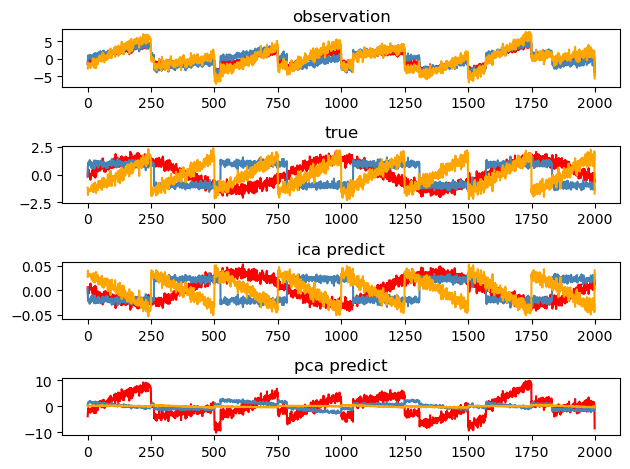

In [32]:
plt.figure()
models = [X , S , S_ , H]
names = [
    'observation' , 'true' , 'ica predict' , 'pca predict'
]

colors = ['red' , 'steelblue' , 'orange']
for ii, (model, name) in enumerate(zip(models , names),1):
    plt.subplot(4,1,ii)
    plt.title(name)
    for sig, color in zip(model.T, colors):
        plt.plot(sig , color)
plt.tight_layout()
plt.show()                                